In [1]:
# ============================================================
#  SUDOKU SOLVER — Computer Vision Final Project
#  Platform: Google Colab (no installation needed)
#  Run each cell in order, top to bottom.
# ============================================================

# ── CELL 1: Install the one extra library needed ─────────────
# (Run this first, then restart runtime if Colab asks you to)

!pip install imutils

In [2]:
# ── CELL 2: Imports ──────────────────────────────────────────

import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
import imutils
from imutils.perspective import four_point_transform
from skimage.segmentation import clear_border
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [25]:
# ── CELL 3: Upload your sudoku image ────────────────────────
# A file picker will appear. Upload any sudoku photo.

uploaded = files.upload()
IMAGE_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {IMAGE_PATH}")


Saving WhatsApp Image 2026-05-16 at 12.48.37 AM.jpeg to WhatsApp Image 2026-05-16 at 12.48.37 AM.jpeg
Uploaded: WhatsApp Image 2026-05-16 at 12.48.37 AM.jpeg


Step 1 — Thresholded image (grid lines highlighted):


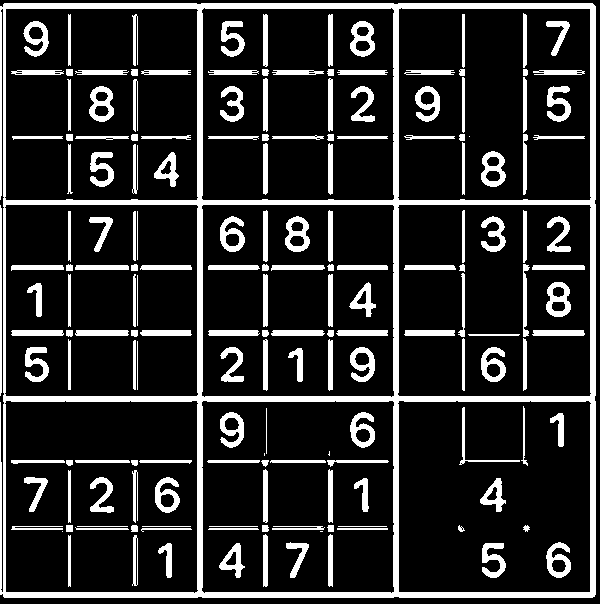


Step 2 — Detected board outline (green):


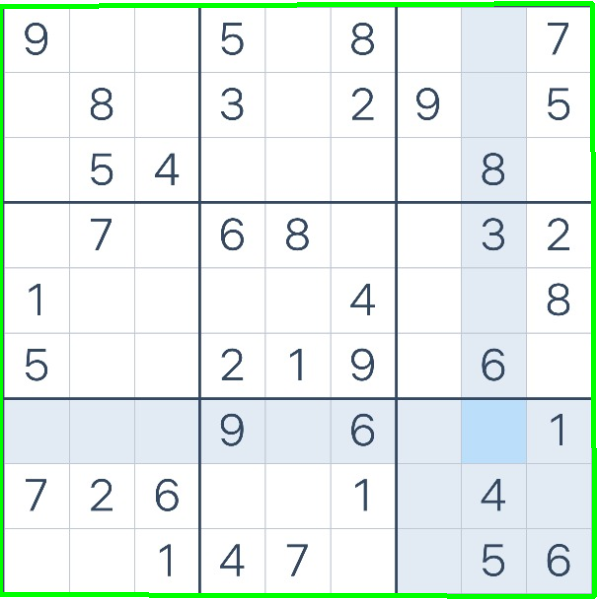


Step 3 — Flattened top-down view of board:


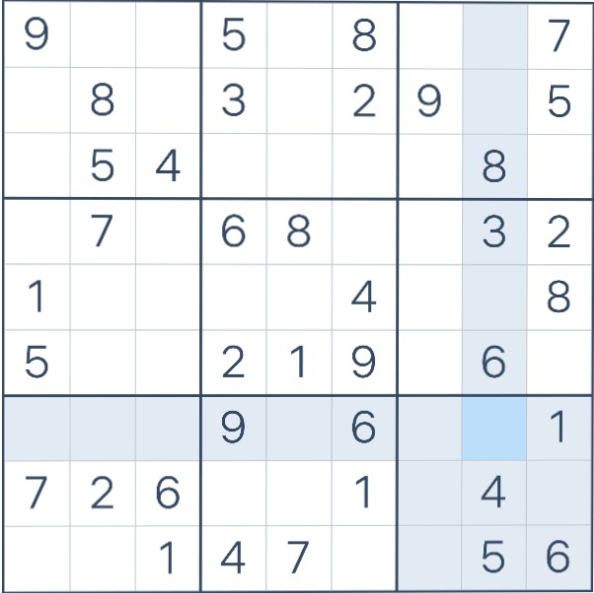

In [26]:
# ── CELL 4: STAGE 1 — Find & extract the sudoku grid ────────

def find_sudoku_board(image_path):
    """
    Loads the image, finds the sudoku grid using contours,
    and returns a top-down flattened view of just the grid.
    """
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError("Image not found. Re-upload and check the path.")

    # Resize for consistent processing
    image = imutils.resize(image, width=600)

    # Convert to grayscale and blur to reduce noise
    gray   = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 3)

    # Adaptive threshold to isolate the grid lines
    thresh = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    print("Step 1 — Thresholded image (grid lines highlighted):")
    cv2_imshow(thresh)

    # Find contours and sort by area (largest = the sudoku board)
    contours = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = imutils.grab_contours(contours)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    board_contour = None
    for c in contours:
        perimeter = cv2.arcLength(c, True)
        approx    = cv2.approxPolyDP(c, 0.02 * perimeter, True)
        if len(approx) == 4:          # Found a rectangle
            board_contour = approx
            break

    if board_contour is None:
        raise Exception("Could not find the sudoku board. Try a clearer image.")

    # Draw the detected outline on a copy
    output = image.copy()
    cv2.drawContours(output, [board_contour], -1, (0, 255, 0), 3)
    print("\nStep 2 — Detected board outline (green):")
    cv2_imshow(output)

    # Flatten — warp perspective so grid is a clean square
    warped = four_point_transform(image, board_contour.reshape(4, 2))
    warped_gray = four_point_transform(gray,  board_contour.reshape(4, 2))

    print("\nStep 3 — Flattened top-down view of board:")
    cv2_imshow(warped)

    return warped, warped_gray


warped_color, warped_gray = find_sudoku_board(IMAGE_PATH)

Step 4 — First row of extracted cells (each cell = one digit box):


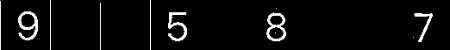

In [28]:
# ── CELL 5: STAGE 2 — Extract each of the 81 cells ──────────

def extract_cells(warped_gray):
    """
    Splits the flattened grid into an 9x9 array of cell images.
    Each cell is a small grayscale image of one digit (or empty).
    """
    # Threshold the warped grid
    thresh = cv2.adaptiveThreshold(
        warped_gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, 11, 2
    )

    h, w   = thresh.shape
    cell_h = h // 9
    cell_w = w // 9

    cells = []
    for row in range(9):
        row_cells = []
        for col in range(9):
            # Crop out this cell with a small margin
            y1 = row * cell_h + 4
            y2 = (row + 1) * cell_h - 4
            x1 = col * cell_w + 4
            x2 = (col + 1) * cell_w - 4
            cell = thresh[y1:y2, x1:x2]
            row_cells.append(cell)
        cells.append(row_cells)

    # Preview the first row of cells
    print("Step 4 — First row of extracted cells (each cell = one digit box):")
    preview = np.hstack([cv2.resize(c, (50, 50)) for c in cells[0]])
    cv2_imshow(preview)

    return cells


cells = extract_cells(warped_gray)

In [ ]:
# ── CELL 6: STAGE 3 — Build & train a digit classifier ──────
# We use the MNIST dataset (handwritten digits) to train a
# small CNN that recognizes digits 1–9.
# The trained model is saved to disk so it only trains once.

import os

MODEL_PATH = "digit_model.h5"

def build_and_train_digit_model():
    """
    Trains a small CNN on MNIST handwritten digits.
    Returns the trained model. Takes ~1–2 minutes on Colab.
    """
    print("Loading MNIST dataset...")
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Normalize and reshape
    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
    x_test  = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

    # One-hot encode labels (0–9 → 10 classes, but we only use 1–9)
    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test  = tf.keras.utils.to_categorical(y_test,  10)

    # Small CNN
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10,  activation='softmax')   # 10 output classes (0–9)
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    print("Training digit recognition model...")
    model.fit(x_train, y_train, epochs=5, batch_size=128,
              validation_data=(x_test, y_test), verbose=1)

    loss, acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"\nModel accuracy on test set: {acc*100:.1f}%")

    return model


# Load saved model if it exists; only train if it doesn't.
# This avoids re-training every time the notebook is run (~1–2 min saved).
if os.path.exists(MODEL_PATH):
    print(f"Loading saved model from '{MODEL_PATH}'...")
    digit_model = tf.keras.models.load_model(MODEL_PATH)
    print("Model loaded successfully.")
else:
    digit_model = build_and_train_digit_model()
    digit_model.save(MODEL_PATH)
    print(f"Model saved to '{MODEL_PATH}' for future runs.")


Loading MNIST dataset...
Training digit recognition model...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 92ms/step - accuracy: 0.9126 - loss: 0.2897 - val_accuracy: 0.9810 - val_loss: 0.0613
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 96ms/step - accuracy: 0.9718 - loss: 0.0959 - val_accuracy: 0.9866 - val_loss: 0.0396
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.9804 - loss: 0.0688 - val_accuracy: 0.9891 - val_loss: 0.0316
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 96ms/step - accuracy: 0.9836 - loss: 0.0550 - val_accuracy: 0.9904 - val_loss: 0.0278
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - accuracy: 0.9866 - loss: 0.0454 - val_accuracy: 0.9898 - val_loss: 0.0299

Model accuracy on test set: 99.0%


In [ ]:
# ── CELL 7: STAGE 4 — Predict digit in each cell ────────────

def is_empty_cell(cell_img):
    """Returns True if a cell appears to be blank (no digit).
     Use a percentage-based check instead of a fixed pixel count
    so it scales correctly across different image sizes and lighting.
    """
    total = cell_img.shape[0] * cell_img.shape[1]
    return cv2.countNonZero(cell_img) / total < 0.03  # less than 3% white pixels = empty


def predict_digit(cell_img, model):
    """
    Preprocesses a cell image and predicts the digit using the CNN.
    Returns 0 if the cell is empty, otherwise the predicted digit (1–9).
    """
    # Clear border artifacts (grid lines bleeding into cell)
    cell_img = clear_border(cell_img)

    if is_empty_cell(cell_img):
        return 0   # 0 means empty

    # Apply blur BEFORE resize (previously these two lines were
    # placed after the return statement and never executed — dead code).
    cell_img = cv2.GaussianBlur(cell_img, (3, 3), 0)

    # Resize to 28x28 (MNIST format)
    cell_resized = cv2.resize(cell_img, (28, 28))
    cell_norm    = cell_resized.astype("float32") / 255.0
    cell_input   = cell_norm.reshape(1, 28, 28, 1)

    prediction = model.predict(cell_input, verbose=0)
    digit      = np.argmax(prediction)

    #  Raised confidence threshold from 0.4 → 0.75.
    # A 10-class model shouldn't accept predictions below ~75% confidence;
    # low-confidence cells are safer treated as empty (recoverable by the solver).
    if np.max(prediction) < 0.75:
        return 0

    return int(digit)


def read_board(cells, model):
    """Returns a 9x9 numpy array of the sudoku board (0 = empty)."""
    board = np.zeros((9, 9), dtype=int)
    for r in range(9):
        for c in range(9):
            board[r][c] = predict_digit(cells[r][c], model)

    print("Step 5 — Board read from image (0 = empty cell):")
    print(board)
    return board


board = read_board(cells, digit_model)


Step 5 — Board read from image (0 = empty cell):
[[9 0 0 5 0 8 0 0 7]
 [0 8 0 3 0 2 9 0 5]
 [0 5 4 0 0 0 0 8 0]
 [0 7 0 6 8 0 0 3 2]
 [7 0 0 0 0 0 0 0 8]
 [5 0 0 2 7 9 0 0 0]
 [0 0 0 0 0 6 0 0 1]
 [7 7 6 0 0 1 0 4 0]
 [0 0 7 6 7 0 0 5 5]]


In [42]:
# ── VALIDATION CELL — checks if board is valid before solving ──

def validate_board(board):
    errors = []

    for i in range(9):
        # Check rows
        row = board[i][board[i] != 0]
        if len(row) != len(set(row)):
            errors.append(f"Duplicate in ROW {i}: {board[i]}")

        # Check columns
        col = board[:, i][board[:, i] != 0]
        if len(col) != len(set(col)):
            errors.append(f"Duplicate in COL {i}: {board[:,i]}")

        # Check 3x3 boxes
        r, c = 3 * (i // 3), 3 * (i % 3)
        box = board[r:r+3, c:c+3].flatten()
        box = box[box != 0]
        if len(box) != len(set(box)):
            errors.append(f"Duplicate in BOX at ({r},{c})")

    if errors:
        print("❌ Board has errors:")
        for e in errors: print(" ", e)
    else:
        print("✅ Board is valid! Safe to solve.")

validate_board(board)

✅ Board is valid! Safe to solve.


In [ ]:
# ── MANUAL OVERRIDE (optional) ───────────────────────────────

# Only run this cell if digit recognition failed and you want to
# manually provide the board. Otherwise SKIP THIS CELL entirely.
#
# To use: uncomment the block below, fill in your board values, and run.

# board = np.array([
#     [9,0,0, 5,0,8, 0,0,7],
#     [0,8,0, 3,0,2, 9,0,5],
#     [0,5,4, 0,0,0, 0,8,0],
#
#     [0,7,0, 6,8,0, 0,3,2],
#     [1,0,0, 0,0,4, 0,0,8],
#     [5,0,0, 2,1,9, 0,6,0],
#
#     [0,0,0, 9,0,6, 0,0,1],
#     [7,2,6, 0,0,1, 0,4,0],
#     [0,0,1, 4,7,0, 0,5,6],
# ])
#
# validate_board(board)
# print("\nManual override active — using hardcoded board, not the CV result.")


✅ Board is valid! Safe to solve.


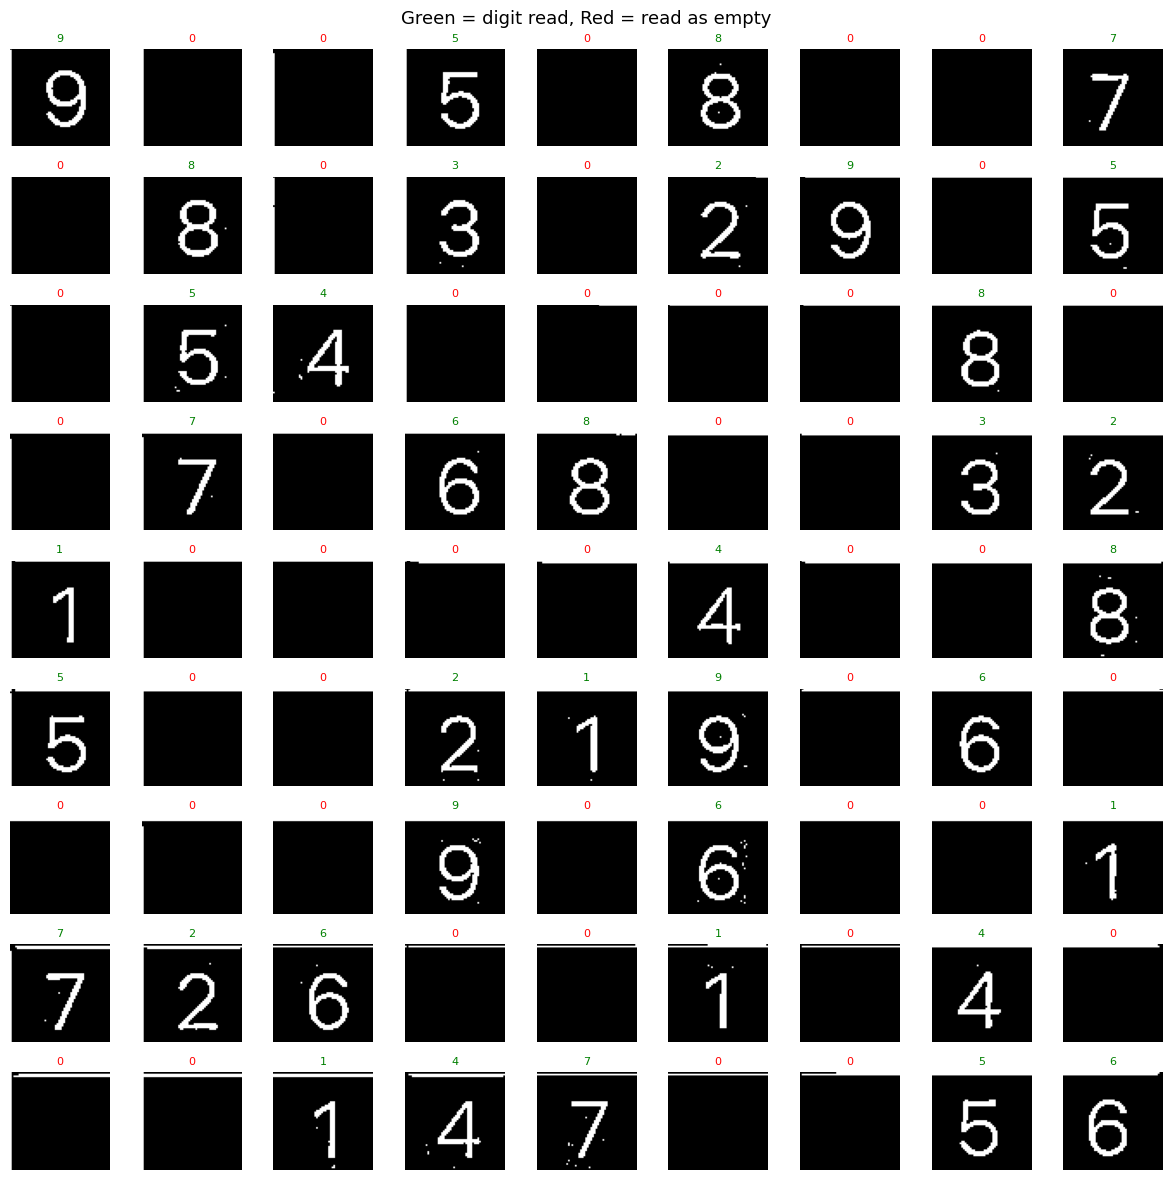

In [40]:
# ── DEBUG CELL — Run this to visually check what was read ──

import matplotlib.pyplot as plt

fig, axes = plt.subplots(9, 9, figsize=(12, 12))

for row in range(9):
    for col in range(9):
        cell_img = cells[row][col]
        axes[row][col].imshow(cell_img, cmap='gray')
        axes[row][col].set_title(str(board[row][col]), fontsize=8, color='green' if board[row][col] != 0 else 'red')
        axes[row][col].axis('off')

plt.suptitle("Green = digit read, Red = read as empty", fontsize=13)
plt.tight_layout()
plt.show()

In [41]:
# ── INTERACTIVE BOARD EDITOR ──
# Prints the board as a grid with coordinates
# So you can visually compare with your image

print("Current board (0 = empty):\n")
print("    C0 C1 C2  C3 C4 C5  C6 C7 C8")
print("   " + "-"*33)
for r in range(9):
    row_str = f"R{r} |"
    for c in range(9):
        row_str += f" {board[r][c]}"
        if c in [2, 5]:
            row_str += " |"
    print(row_str)
    if r in [2, 5]:
        print("   " + "-"*33)

Current board (0 = empty):

    C0 C1 C2  C3 C4 C5  C6 C7 C8
   ---------------------------------
R0 | 9 0 0 | 5 0 8 | 0 0 7
R1 | 0 8 0 | 3 0 2 | 9 0 5
R2 | 0 5 4 | 0 0 0 | 0 8 0
   ---------------------------------
R3 | 0 7 0 | 6 8 0 | 0 3 2
R4 | 1 0 0 | 0 0 4 | 0 0 8
R5 | 5 0 0 | 2 1 9 | 0 6 0
   ---------------------------------
R6 | 0 0 0 | 9 0 6 | 0 0 1
R7 | 7 2 6 | 0 0 1 | 0 4 0
R8 | 0 0 1 | 4 7 0 | 0 5 6


In [43]:
# ── CELL 8: STAGE 5 — Solve the sudoku (backtracking) ───────

def is_valid(board, row, col, num):
    """Check if placing 'num' at board[row][col] is valid."""
    # Check row
    if num in board[row]:
        return False
    # Check column
    if num in board[:, col]:
        return False
    # Check 3×3 box
    box_r, box_c = 3 * (row // 3), 3 * (col // 3)
    if num in board[box_r:box_r+3, box_c:box_c+3]:
        return False
    return True


def solve_sudoku(board):
    """
    Solves the sudoku in-place using backtracking.
    Returns True if solved, False if no solution exists.
    """
    for row in range(9):
        for col in range(9):
            if board[row][col] == 0:          # found an empty cell
                for num in range(1, 10):
                    if is_valid(board, row, col, num):
                        board[row][col] = num
                        if solve_sudoku(board):   # recurse
                            return True
                        board[row][col] = 0       # backtrack
                return False   # no valid number found → backtrack further
    return True   # all cells filled


solved_board = board.copy()
if solve_sudoku(solved_board):
    print("Step 6 — Solved board:")
    print(solved_board)
else:
    print("Could not solve the puzzle. The digit recognition may have made errors.")
    print("Check the board read above and correct any mistakes manually.")


Step 6 — Solved board:
[[9 1 3 5 6 8 4 2 7]
 [6 8 7 3 4 2 9 1 5]
 [2 5 4 1 9 7 6 8 3]
 [4 7 9 6 8 5 1 3 2]
 [1 6 2 7 3 4 5 9 8]
 [5 3 8 2 1 9 7 6 4]
 [3 4 5 9 2 6 8 7 1]
 [7 2 6 8 5 1 3 4 9]
 [8 9 1 4 7 3 2 5 6]]


Step 7 — Final solved puzzle (green = filled in by solver):


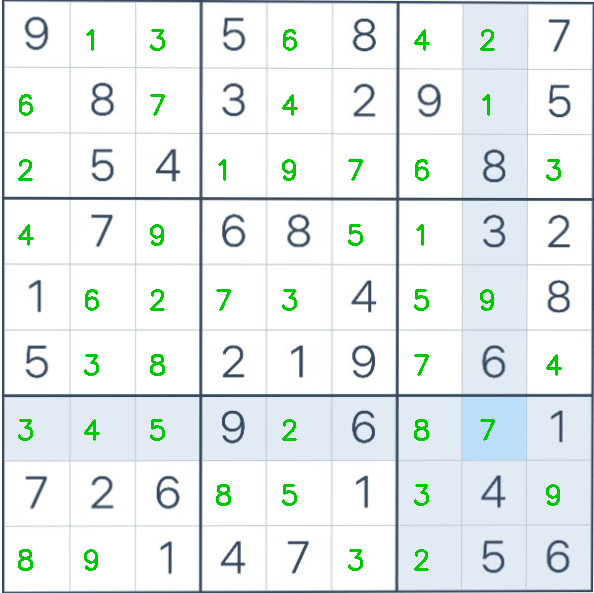

In [44]:
# ── CELL 9: STAGE 6 — Overlay solution onto original image ──

def overlay_solution(warped_color, original_board, solved_board):
    """
    Draws the solved digits (in green) on top of the warped grid image.
    Only draws digits that were originally empty (0).
    """
    output   = warped_color.copy()
    h, w, _  = output.shape
    cell_h   = h // 9
    cell_w   = w // 9

    for row in range(9):
        for col in range(9):
            if original_board[row][col] == 0:   # only fill in blanks
                digit = str(solved_board[row][col])

                # Center the text in the cell
                x = col * cell_w + cell_w // 4
                y = (row + 1) * cell_h - cell_h // 4

                cv2.putText(
                    output, digit,
                    (x, y),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    fontScale=0.9,
                    color=(0, 200, 0),   # Green
                    thickness=2
                )

    print("Step 7 — Final solved puzzle (green = filled in by solver):")
    cv2_imshow(output)
    return output


final_image = overlay_solution(warped_color, board, solved_board)



In [45]:
# ── CELL 10: Save the result ─────────────────────────────────

cv2.imwrite("solved_sudoku.jpg", final_image)
files.download("solved_sudoku.jpg")
print("Done! Your solved sudoku has been downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Your solved sudoku has been downloaded.
